Dataset shape: (712, 16)


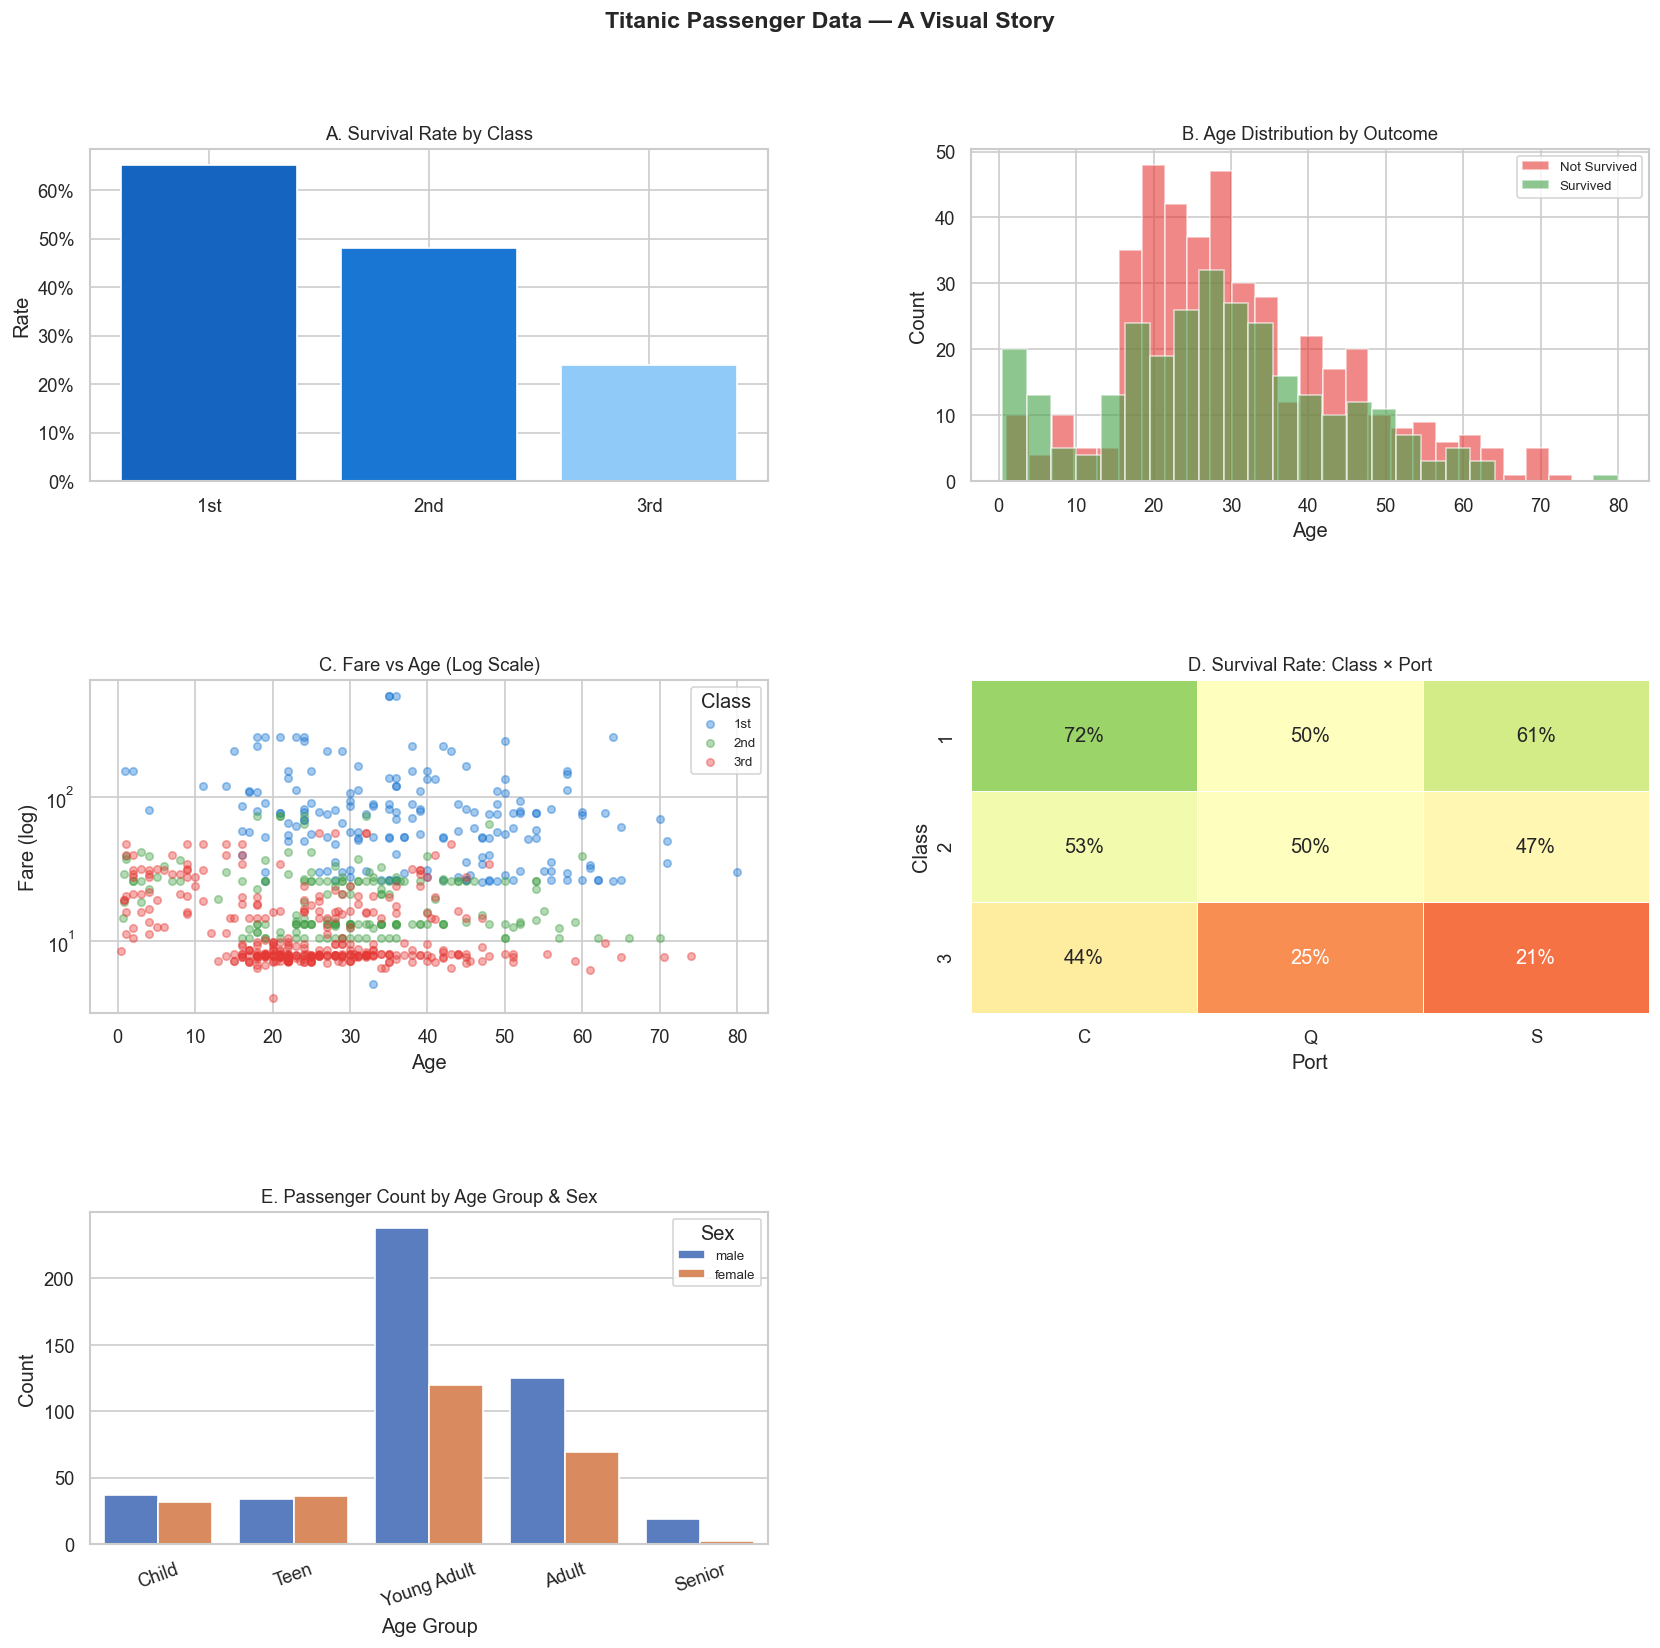

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Display settings
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# Load dataset
df = pd.read_excel('titanic_dataset.xlsx')
df = df.dropna(subset=['age', 'embarked'])

# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 12, 18, 35, 60, 120],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

print("Dataset shape:", df.shape)

# Create 3x2 grid (6 slots, 5 charts used)
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Dashboard title
fig.suptitle(
    'Titanic Passenger Data — A Visual Story',
    fontsize=14,
    fontweight='bold',
    y=0.98
)

# ─────────────────────────────────────────────
# Panel A: Survival Rate by Class
# ─────────────────────────────────────────────
ax = axes[0, 0]

surv = df.groupby('pclass')['survived'].mean()

ax.bar(
    ['1st', '2nd', '3rd'],
    surv.values,
    color=['#1565C0', '#1976D2', '#90CAF9']
)

ax.set_title('A. Survival Rate by Class', fontsize=11)
ax.set_ylabel('Rate')
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))

# ─────────────────────────────────────────────
# Panel B: Age Distribution by Survival
# ─────────────────────────────────────────────
ax = axes[0, 1]

ax.hist(
    df[df['survived'] == 0]['age'],
    bins=25,
    alpha=0.6,
    color='#E53935',
    label='Not Survived'
)

ax.hist(
    df[df['survived'] == 1]['age'],
    bins=25,
    alpha=0.6,
    color='#43A047',
    label='Survived'
)

ax.set_title('B. Age Distribution by Outcome', fontsize=11)
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend(fontsize=8)

# ─────────────────────────────────────────────
# Panel C: Fare vs Age Scatter Plot
# ─────────────────────────────────────────────
ax = axes[1, 0]

for cls, color, label in zip(
    [1, 2, 3],
    ['#1976D2', '#43A047', '#E53935'],
    ['1st', '2nd', '3rd']
):
    subset = df[df['pclass'] == cls]

    ax.scatter(
        subset['age'],
        subset['fare'],
        color=color,
        alpha=0.4,
        s=20,
        label=label
    )

ax.set_yscale('log')
ax.set_title('C. Fare vs Age (Log Scale)', fontsize=11)
ax.set_xlabel('Age')
ax.set_ylabel('Fare (log)')
ax.legend(title='Class', fontsize=8)

# ─────────────────────────────────────────────
# Panel D: Survival Heatmap
# ─────────────────────────────────────────────
ax = axes[1, 1]

pivot = df.pivot_table(
    values='survived',
    index='pclass',
    columns='embarked',
    aggfunc='mean'
)

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0%',
    cmap='RdYlGn',
    linewidths=0.5,
    vmin=0,
    vmax=1,
    cbar=False,
    ax=ax
)

ax.set_title('D. Survival Rate: Class × Port', fontsize=11)
ax.set_xlabel('Port')
ax.set_ylabel('Class')

# ─────────────────────────────────────────────
# Panel E: Passenger Count by Age Group & Sex
# ─────────────────────────────────────────────
ax = axes[2, 0]

sns.countplot(
    data=df,
    x='age_group',
    hue='sex',
    order=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'],
    ax=ax
)

ax.set_title('E. Passenger Count by Age Group & Sex', fontsize=11)
ax.set_xlabel('Age Group')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Sex', fontsize=8)

# Remove unused 6th panel
fig.delaxes(axes[2, 1])

# Layout adjustments
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.6, wspace=0.3)

# Save dashboard
plt.savefig(
    'titanic_dashboard.png',
    dpi=300,
    bbox_inches='tight'
)

# Show dashboard
plt.show()